In [10]:
import os
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader,random_split

from Tools.model_tools import*
from Tools.data_utils import SimulationData,generate_input_filename
from Encoder import*

## Training the Decoder:

In this notebook, we train a Variational Autoencoder (VAE) to reconstruct the dynamics of $ y_2(t) $ from the embeddings of $ y_1(t) $. The VAE leverages an encoder pre-trained in `trainEncoder.ipynb`, with its weights frozen to ensure the latent representation remains unchanged. Only the decoder is trained, focusing solely on a reconstruction loss, as the shared latent dynamics have already been learned.

The framework for this process can be summarized as follows:  
Given the projection of the Hankel matrix associated with the scalar observable $ y_i(t) $, where $ \hat{y}_i(t_i) $ denotes the $ i $-th column of the projected matrix:

$
\begin{equation}
z = \text{Encoder}(\hat{y}_1(t_i)),  
\quad \hat{y}_2(t_i) = \text{Decoder}(z)
\end{equation}
$

This approach emphasizes the reconstruction of the vector observable $ y_2 $, leveraging the shared latent dynamics captured by the encoder.

#### Input dataset:

Insert the parameters of the Dataset to use for training the data

In [11]:
tau = 3
embedding_dim = 30
r = 20
alpha = 21
beta = 0

simulation_name= generate_input_filename(tau, embedding_dim, r, alpha, beta)
print(simulation_name)

# Carica i dati di simulazione
simulation = SimulationData.load_from_params(
    tau=tau, embedding_dim=embedding_dim, alpha=alpha, beta=beta, r=r, input_path="Simulation data"
)

delay3dim30,20_noise21,0


### Loading the configurations:
The code loads all available configurations and selects one from the existing options.

In [12]:
# Percorso del database
encoder_database_path = "encoderDatabase.json"
# Carica tutte le configurazioni disponibili
all_configs = load_configs(encoder_database_path)

encoder_name = "30,20-Noise21,0"
decoder_name = "30,20-Noise21,0"
encoder_config = get_model_config_by_name(encoder_database_path, encoder_name)
print(encoder_config)


{'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim30,20_noise21,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}


### VAE configuration:

Define the configuration of the Variational Autoencoder (VAE).
In this section, you can modify the decoder architecture, hyperparameters, and training settings of the VAE.

Additionally, the model name serves as an identifier to differentiate between networks that share the same parameters but are trained using different configurations or options.

In [13]:
decoder_database_path = "decoderDatabase.json"

#Parametri per configurare il decoder
output_dim = 2*r
input_dim = encoder_config["latent_dim"]

# Importanti per il training:
decoder_layers = [input_dim,20,output_dim]
gamma = 2.0

latent_dim = encoder_config["latent_dim"]
if latent_dim != decoder_layers[0]:
    decoder_layers.append(latent_dim)

# Se vuoi creare una nuova configurazione
decoder_config = {
    "decoder_layers": decoder_layers,
    "latent_dim": latent_dim,
    "early_stopping": {"patience": 10, "delta": -1}, # Early stopping -1 per disattivare
    "dataset": simulation_name,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 0.02,
    "gamma" : gamma, # Valore che pesa la loss di Z3
    "scheduler": {
        "type": "ReduceLROnPlateau", 
        "params": {

            # Parametri per ReduceLROnPlateau
            "mode": "min",      # Monitora la perdita minima
            "factor": 0.5,      # Fattore di riduzione (LR = LR * factor)
            "patience": 10,     # Numero di epoche senza miglioramenti prima di ridurre LR
            "min_lr": 1e-09 ,  # Limite inferiore per il LR

            # Parametri per CyclicLR
            "base_lr": 0.0001,  # Minimo LR per CyclicLR
            "max_lr": 0.01,     # Massimo LR per CyclicLR
            "step_size_up": 200,  # Numero di step per aumentare il LR (solo per CyclicLR)

            # Parametri per CosineAnnealingLR
            "T_max": 100,       # Numero di step fino al minimo (solo per CosineAnnealingLR)

            # Parametri per CosineAnnealingWarmRestarts
            "T_0": 10,          # Numero di step per il primo ciclo (solo per CosineAnnealingWarmRestarts)
            "T_mult": 2,        # Fattore moltiplicativo per il ciclo successivo (solo per CosineAnnealingWarmRestarts)
            "eta_min": 0.00000001,  # Valore minimo per CosineAnnealingLR e CosineAnnealingWarmRestarts
        }
    },
    "Encoder": encoder_name # Encoder usato per allenare il decoder
}

epochs = 300

print(all_configs)

{'Model_1': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim100,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_lr': 0.0001, 'max_lr': 0.01, 'step_size_up': 200, 'T_max': 100, 'T_0': 10, 'T_mult': 2, 'eta_min': 1e-08}}}, 'NoLeg': {'layer_dims': [20, 15, 10, 5], 'latent_dim': 5, 'beta_method': 'sigmoid', 'beta_value': 0.01, 'kl_annealing_epochs': 250, 'decay_start': 100, 'decay_epoch': 50, 'early_stopping': {'patience': 10, 'delta': -1}, 'dataset': 'delay3dim20,20_noise0,0', 'batch_size': 32, 'optimizer': 'Adam', 'learning_rate': 0.02, 'scheduler': {'type': 'ReduceLROnPlateau', 'params': {'mode': 'min', 'factor': 0.5, 'patience': 10, 'min_lr': 1e-09, 'base_l

### Dataset Creation and Preparation for the Decoder

This section creates the dataset and prepares it for training and validation. The dataset is initialized using the reduced matrices $ y_1 $, $ y_{2,1} $, and $ y_{2,2} $, and their shapes are printed to verify correctness.

The dataset is then split into training (60%) and validation (40%) subsets without randomization, ensuring a deterministic partition. The total dataset size is also printed for confirmation.
Data loaders are configured for both training and validation subsets, with the training loader enabling shuffling for random batch generation, while the validation loader maintains a fixed order.

Finally, a batch is loaded from the training data to debug its structure. The input and target tensors are inspected for their shapes:
- Inputs ($ y_1 $): batch size $\times$ embedding dimension ($r$).
- Targets ($ y_2 $): batch size $\times$ $2r$, corresponding to the concatenated dimensions of $ z_1 $ and $ z_3 $. These are further decomposed into their respective components to ensure correctness.

This step ensures the data is prepared and structured correctly for training the decoder.

In [14]:
# Seleziona le matrici di Hankel da SimulationData
y1_reduced_data = simulation.projected_H1
y2_1_reduced_data = simulation.projected_H2_1
y2_2_reduced_data = simulation.projected_H2_2

if y1_reduced_data is None or y2_1_reduced_data is None or y2_2_reduced_data is None:
    raise ValueError("Uno o più embedding non sono stati generati correttamente!")



In [15]:
# Crea il dataset
embedded_dataset = EmbeddedDatasetforDecoder(y1_reduced_data, y2_1_reduced_data, y2_2_reduced_data)

print("y1 Matrix shape:", y1_reduced_data.shape)  # Deve essere (n_samples, embedding_dim)
print(f"y2_1 Matrix shape: {y2_1_reduced_data.shape}")
print(f"y2_2 Matrix shape: {y2_2_reduced_data.shape}")

# Suddivisione del dataset
total_size = len(embedded_dataset)
train_size = int(0.60 * total_size)  # 60% per il training
val_size = total_size - train_size   # 40% per la validazione

# Suddivisione del dataset senza random split
train_data = torch.utils.data.Subset(embedded_dataset, range(train_size))
val_data = torch.utils.data.Subset(embedded_dataset, range(train_size, total_size))

# Stampa delle dimensioni
print(f"Dimensione del dataset: {total_size}")

# Prepara il DataLoader
batch_size = decoder_config["batch_size"]
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

# Debug del batch
for batch in train_loader:
    inputs, targets = batch  # Decomponi input e target
    inputs = inputs.float()
    targets = targets.float()
    print("Shape of input:", inputs.shape) # Batch size x r (dimensione del singolo sample di y1)
    print("Shape of target:", targets.shape) # Batch size x 2*r (dimensione del singolo sample di y2)

    z1_target = targets[:, :r]
    z3_target = targets[:, r:]

    print("Shape of z1_target:", z1_target.shape)
    print("Shape of z3_target:", z3_target.shape)

    break

y1 Matrix shape: (20, 9913)
y2_1 Matrix shape: (20, 9913)
y2_2 Matrix shape: (20, 9913)
Dimensione del dataset: 9913
Shape of input: torch.Size([32, 20])
Shape of target: torch.Size([32, 40])
Shape of z1_target: torch.Size([32, 20])
Shape of z3_target: torch.Size([32, 20])


### Loading the Pretrained Encoder

In this section, the pretrained encoder model is loaded from the specified directory and checkpoint file. The `load_encoder` function initializes the encoder with its saved parameters.

To ensure the encoder's weights remain unchanged during the training process, all its parameters are frozen by setting `requires_grad` to `False`. A list of parameter names and their corresponding `requires_grad` status is printed for verification.

This setup ensures that the encoder's learned representations are preserved while focusing training exclusively on the decoder.

In [16]:
#Caricamento del modello preallenato dell'encoder
encoder_model_path = "Encoder Models"
encoder_path = os.path.join(encoder_model_path, encoder_name + ".pth")

encoder, encoder_checkpoint = load_encoder(encoder_path, Encoder)

# Congela i parametri dell'encoder per impedire l'allenamento
for param in encoder.parameters():
    param.requires_grad = False
# Stampa i nomi e lo stato di requires_grad per i parametri dell'encoder
print("Parametri dell'encoder:")
for name, param in encoder.named_parameters():
    print(f"{name}: requires_grad={param.requires_grad}")


Encoder and training info loaded from Encoder Models/30,20-Noise21,0.pth
Parametri dell'encoder:
encoder.0.weight: requires_grad=False
encoder.0.bias: requires_grad=False
encoder.2.weight: requires_grad=False
encoder.2.bias: requires_grad=False
fc_mu.weight: requires_grad=False
fc_mu.bias: requires_grad=False
fc_log_var.weight: requires_grad=False
fc_log_var.bias: requires_grad=False


/workspaces/Lorenz-Toy/Tools/training_tools.py:383: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path)


### Creating the VAE and Training the Decoder

The VAE is constructed using the pretrained encoder (frozen) and a new decoder with reversed layer configuration. An optimizer is configured to train only the decoder parameters, with a scheduler set according to the configuration.

The decoder is trained using the `reconstruct_y2fromy1` function to reconstruct \( y_2 \) from \( y_1 \) embeddings, tracking reconstruction losses, gradient history, and learning rate evolution. Early stopping is applied to optimize training efficiency.

Epoch [1/300], Training Loss: 0.000701, lr = 0.02
Z1 Loss: 0.000441, Z3 Loss: 0.000260
Epoch [2/300], Training Loss: 0.000474, lr = 0.02
Z1 Loss: 0.000377, Z3 Loss: 0.000097
Epoch [3/300], Training Loss: 0.000461, lr = 0.02
Z1 Loss: 0.000366, Z3 Loss: 0.000095
Epoch [4/300], Training Loss: 0.000453, lr = 0.02
Z1 Loss: 0.000361, Z3 Loss: 0.000093
Epoch [5/300], Training Loss: 0.000448, lr = 0.02
Z1 Loss: 0.000357, Z3 Loss: 0.000091
Epoch [6/300], Training Loss: 0.000445, lr = 0.02
Z1 Loss: 0.000356, Z3 Loss: 0.000089
Epoch [7/300], Training Loss: 0.000441, lr = 0.02
Z1 Loss: 0.000353, Z3 Loss: 0.000088
Epoch [8/300], Training Loss: 0.000435, lr = 0.02
Z1 Loss: 0.000349, Z3 Loss: 0.000086
Epoch [9/300], Training Loss: 0.000435, lr = 0.02
Z1 Loss: 0.000350, Z3 Loss: 0.000084
Epoch [10/300], Training Loss: 0.000435, lr = 0.02
Z1 Loss: 0.000350, Z3 Loss: 0.000085
Epoch [11/300], Training Loss: 0.000434, lr = 0.02
Z1 Loss: 0.000349, Z3 Loss: 0.000084
Epoch [12/300], Training Loss: 0.000433, 

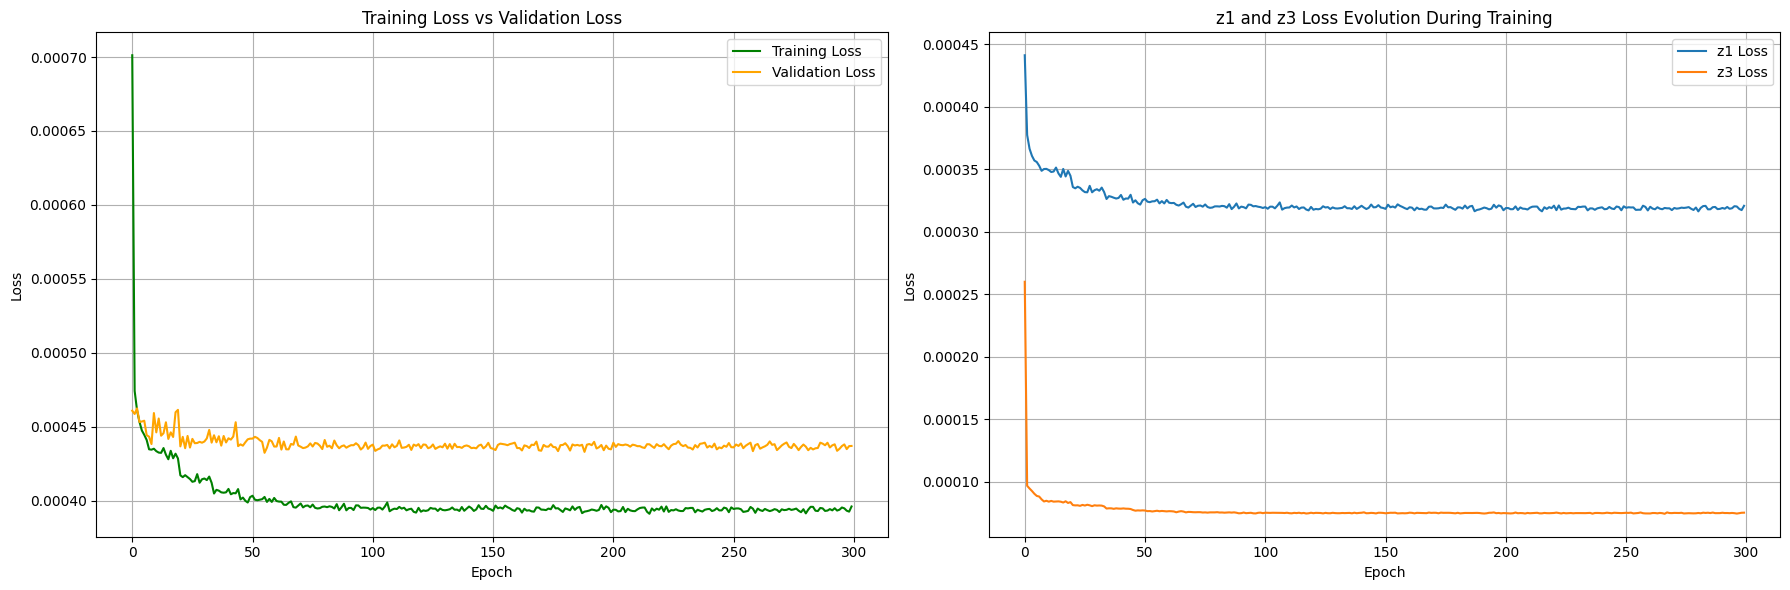

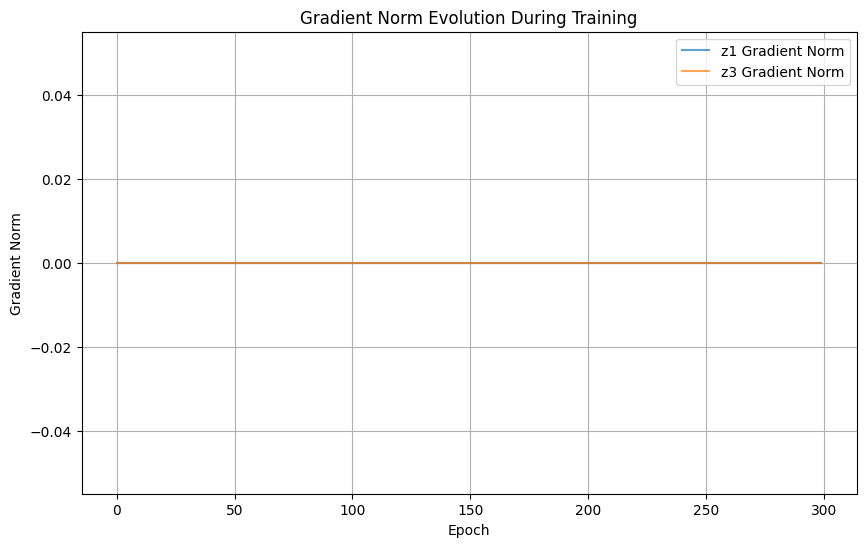

In [17]:
# Creazione del VAE con Decoder da allenare
decoder_layers_reversed = decoder_layers[::-1]
decoder = Decoder(decoder_layers_reversed)
vae_model = VAE(encoder,decoder)


# Configurazione Ottimizzatore e Scheduler

optimizer = optim.Adam(filter(lambda p: p.requires_grad, vae_model.parameters()), lr=decoder_config["learning_rate"])
scheduler_config = decoder_config.get("scheduler")
scheduler = get_scheduler(optimizer, scheduler_config)

# Allenamento del Decoder:
train_losses, val_losses, stopped_epoch, gradient_history, lr_evolution, z1_losses, z3_losses = reconstruct_y2fromy1(
    r = r, gamma=gamma, epochs=epochs,
    train_loader=train_loader,
    val_loader=val_loader,  # Aggiungi se hai un dataset di validazione
    model=vae_model,
    optimizer=optimizer,
    scheduler=scheduler,
    scheduler_config=scheduler_config,
    early_stopping_params=decoder_config["early_stopping"]
)

In [18]:
# Aggiungi la nuova configurazione al database (eventualmente sovrascrive)

add_config(decoder_config, decoder_name, decoder_database_path)

decoder_model_folder = "Decoder Models"
decoder_name += ".pth"


#Salva il modello allenato
save_decoder(decoder=decoder,decoder_layers=decoder_layers ,
            train_losses=train_losses, val_losses=val_losses,
            train_data=train_data, val_data=val_data, epoch=epochs, stopped_epoch=stopped_epoch, 
            gradient_history=gradient_history, lr_evolution=lr_evolution, z1_losses=z1_losses, z3_losses=z3_losses,
            output_folder=decoder_model_folder, decoder_name = decoder_name)

Decoder and training info saved to Decoder Models/30,20-Noise21,0.pth
